# 02. Preprocesamiento del consumo eléctrico

Este cuaderno prepara el problema de regresión como una predicción temporal de la energía activa global. Los predictores finales no incluyen variables contemporáneas físicamente vinculadas con el objetivo, con el fin de mantener un escenario de predicción realista.


#### Índice

1. Librerías utilizadas.
2. Carga del conjunto de datos original.
3. Agregación horaria.
4. Creación de variables temporales y retardos.
5. Partición temporal.
6. Guardado de datos y tablas.


## 1. Librerías utilizadas


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carga del conjunto de datos original

El archivo original presenta una frecuencia de un minuto. En este bloque se conserva la fecha junto con la variable objetivo y se documentan las variables contemporáneas que no se utilizarán como predictores finales.


In [2]:
ruta_datos = "../../data/raw/regresion/household_power_consumption.txt"
power_raw = pd.read_csv(ruta_datos, sep=";", na_values="?", low_memory=False)

power_raw["datetime"] = pd.to_datetime(
    power_raw["Date"] + " " + power_raw["Time"],
    dayfirst=True,
    errors="coerce",
)

columnas_medidas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

for columna in columnas_medidas:
    power_raw[columna] = pd.to_numeric(power_raw[columna], errors="coerce")

power_raw.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [3]:
variables_excluidas_regresion = pd.DataFrame([
    {"variable": "Global_reactive_power", "motivo": "medida contemporánea del mismo instante"},
    {"variable": "Voltage", "motivo": "medida física contemporánea"},
    {"variable": "Global_intensity", "motivo": "muy ligada físicamente a la potencia activa"},
    {"variable": "Sub_metering_1", "motivo": "submedición contemporánea del consumo"},
    {"variable": "Sub_metering_2", "motivo": "submedición contemporánea del consumo"},
    {"variable": "Sub_metering_3", "motivo": "submedición contemporánea del consumo"},
])

variables_excluidas_regresion

,variable,motivo
0,Global_reactive_power,medida contemporánea del mismo instante
1,Voltage,medida física contemporánea
2,Global_intensity,muy ligada físicamente a la potencia activa
3,Sub_metering_1,submedición contemporánea del consumo
4,Sub_metering_2,submedición contemporánea del consumo
5,Sub_metering_3,submedición contemporánea del consumo


## 3. Agregación horaria

La serie se ordena cronológicamente y se agrega con frecuencia horaria. La variable objetivo resultante es `Global_active_energy_kwh`, mientras que los predictores finales se construyen exclusivamente a partir de información temporal y valores pasados.


In [4]:
power = power_raw[["datetime", "Global_active_power"]].dropna().copy()
power = power.sort_values("datetime")

power_horario = (
    power.set_index("datetime")
    .resample("h")
    .agg(
        Global_active_energy_kwh=("Global_active_power", lambda x: x.sum() / 60),
        observaciones_validas=("Global_active_power", "count")
    )
    .reset_index()
)

power_horario = power_horario[
    power_horario["observaciones_validas"] == 60
].copy()

power_horario = power_horario.drop(columns=["observaciones_validas"])

resumen_horario = pd.DataFrame([{
    "observaciones_horarias": len(power_horario),
    "fecha_inicio": power_horario["datetime"].min(),
    "fecha_fin": power_horario["datetime"].max(),
    "media_global_active_energy_kwh": power_horario["Global_active_energy_kwh"].mean(),
    "desviacion_global_active_energy_kwh": power_horario["Global_active_energy_kwh"].std(),
}])

resumen_horario

,observaciones_horarias,fecha_inicio,fecha_fin,media_global_active_energy_kwh,desviacion_global_active_energy_kwh
0,34085,2006-12-16 18:00:00,2010-11-26 20:00:00,1.090361,0.896738


## 4. Creación de variables temporales y retardos

Los retardos y las medias móviles se calculan únicamente con información pasada. Para evitar fugas de información, las medias móviles parten de `shift(1)`, de modo que el valor del instante que se desea predecir no interviene en la construcción de sus predictores.


In [5]:
power_horario["hour"] = power_horario["datetime"].dt.hour
power_horario["day_of_week"] = power_horario["datetime"].dt.dayofweek
power_horario["month"] = power_horario["datetime"].dt.month
power_horario["day"] = power_horario["datetime"].dt.day
power_horario["is_weekend"] = power_horario["day_of_week"].isin([5, 6]).astype(int)

objetivo_regresion = "Global_active_energy_kwh"

for retardo in [1, 2, 24, 48, 168]:
    power_horario[f"lag_{retardo}h"] = power_horario[objetivo_regresion].shift(retardo)

serie_pasada = power_horario[objetivo_regresion].shift(1)

power_horario["rolling_mean_24h"] = serie_pasada.rolling(24).mean()
power_horario["rolling_std_24h"] = serie_pasada.rolling(24).std()
power_horario["rolling_mean_168h"] = serie_pasada.rolling(168).mean()
power_horario["rolling_std_168h"] = serie_pasada.rolling(168).std()

power_modelo = power_horario.dropna().reset_index(drop=True)

variables_finales_regresion = pd.DataFrame({
    "variable": [
        col for col in power_modelo.columns 
        if col not in ["datetime", objetivo_regresion]
    ],
})

variables_finales_regresion["tipo"] = np.where(
    variables_finales_regresion["variable"].str.startswith("lag_") |
    variables_finales_regresion["variable"].str.startswith("rolling_"),
    "información pasada",
    "calendario",
)

variables_finales_regresion

,variable,tipo
0,hour,calendario
1,day_of_week,calendario
2,month,calendario
3,day,calendario
4,is_weekend,calendario
5,lag_1h,información pasada
6,lag_2h,información pasada
7,lag_24h,información pasada
8,lag_48h,información pasada
9,lag_168h,información pasada


In [6]:
valores_ausentes_modelo = power_modelo.isna().sum().reset_index()
valores_ausentes_modelo.columns = ["variable", "n_ausentes"]
valores_ausentes_modelo

,variable,n_ausentes
0,datetime,0
1,Global_active_energy_kwh,0
2,hour,0
3,day_of_week,0
4,month,0
5,day,0
6,is_weekend,0
7,lag_1h,0
8,lag_2h,0
9,lag_24h,0


## 5. Partición temporal

La división no se realiza de forma aleatoria. El primer 80 % de la serie se destina al entrenamiento y el 20 % final a la prueba, respetando en todo momento el orden cronológico de las observaciones.


In [7]:
n_train = int(len(power_modelo) * 0.80)
power_train = power_modelo.iloc[:n_train].copy()
power_test = power_modelo.iloc[n_train:].copy()

resumen_split_temporal = pd.DataFrame([
    {
        "partición": "train",
        "observaciones": len(power_train),
        "fecha_inicio": power_train["datetime"].min(),
        "fecha_fin": power_train["datetime"].max(),
    },
    {
        "partición": "test",
        "observaciones": len(power_test),
        "fecha_inicio": power_test["datetime"].min(),
        "fecha_fin": power_test["datetime"].max(),
    },
])

resumen_split_temporal

,partición,observaciones,fecha_inicio,fecha_fin
0,train,27133,2006-12-23 19:00:00,2010-02-06 15:00:00
1,test,6784,2010-02-06 16:00:00,2010-11-26 20:00:00


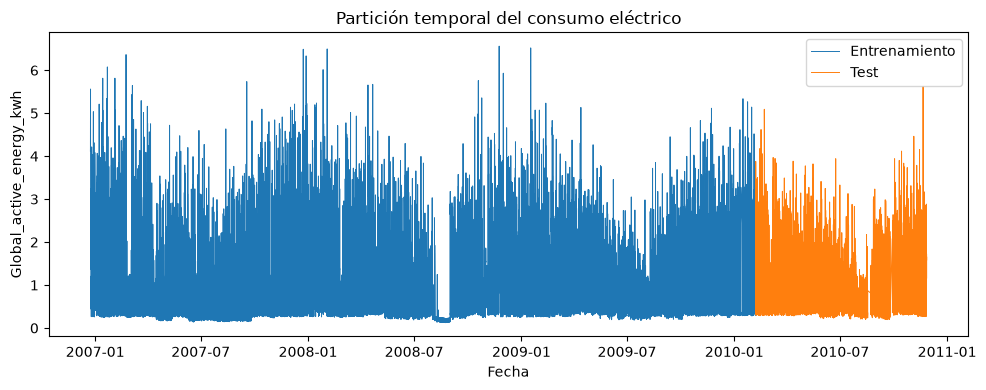

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(power_train["datetime"], power_train[objetivo_regresion], linewidth=0.7, label="Entrenamiento")
ax.plot(power_test["datetime"], power_test[objetivo_regresion], linewidth=0.7, label="Test")
ax.set_title("Partición temporal del consumo eléctrico")
ax.set_xlabel("Fecha")
ax.set_ylabel(objetivo_regresion)
ax.legend()
fig.tight_layout()
plt.show()

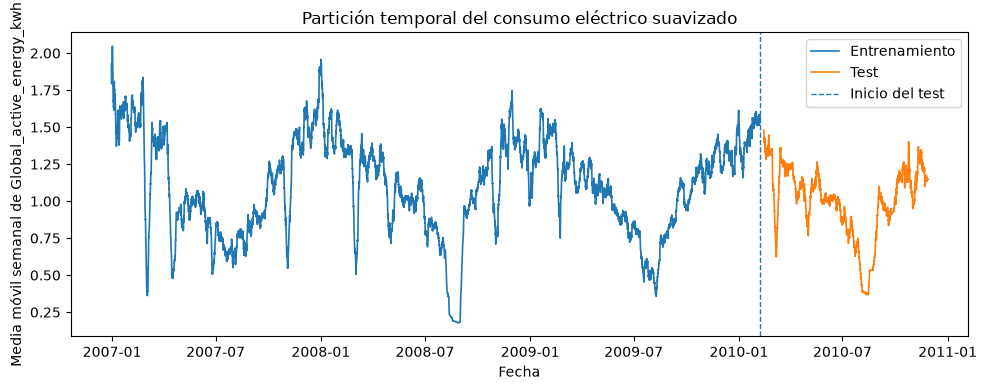

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

train_suavizado = power_train.set_index("datetime")[objetivo_regresion].rolling(168).mean()
test_suavizado = power_test.set_index("datetime")[objetivo_regresion].rolling(168).mean()

ax.plot(train_suavizado.index, train_suavizado, linewidth=1.2, label="Entrenamiento")
ax.plot(test_suavizado.index, test_suavizado, linewidth=1.2, label="Test")

ax.axvline(
    power_test["datetime"].min(),
    linestyle="--",
    linewidth=1,
    label="Inicio del test"
)

ax.set_title("Partición temporal del consumo eléctrico suavizado")
ax.set_xlabel("Fecha")
ax.set_ylabel("Media móvil semanal de " + objetivo_regresion)
ax.legend()

fig.tight_layout()
plt.show()

## 6. Guardado de datos y tablas

En este bloque se guardan los conjuntos de entrenamiento y prueba, junto con las tablas de apoyo obtenidas durante el preprocesamiento de la serie temporal.


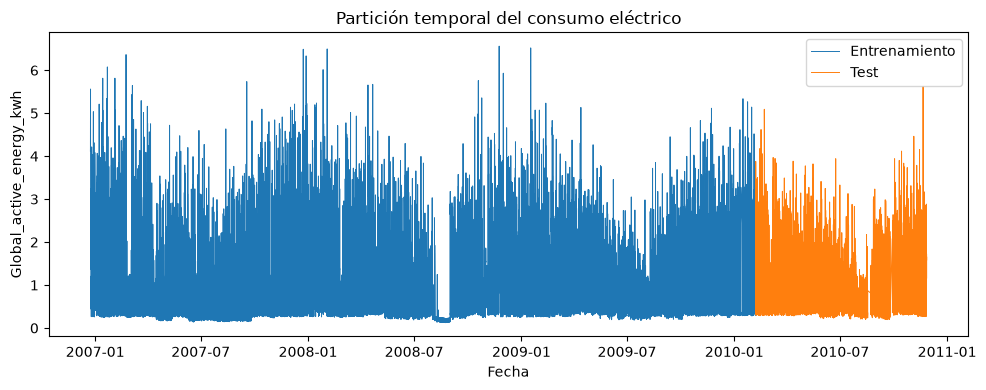

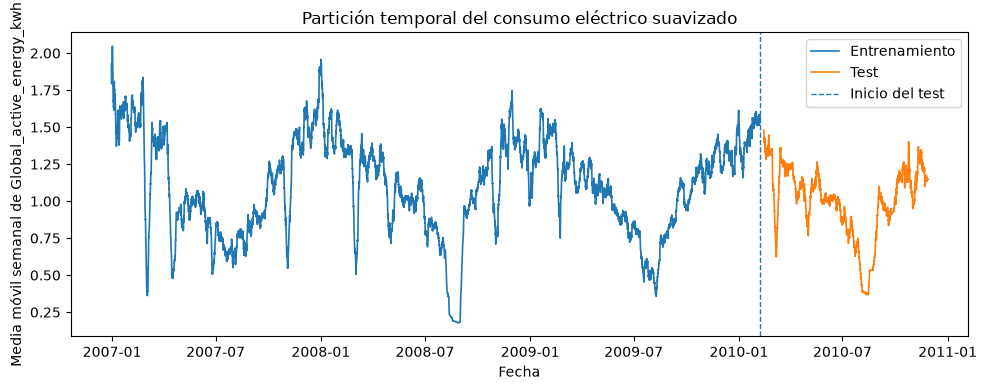

,archivo
0,data/processed/serie_computacional/power_train...
1,data/processed/serie_computacional/power_test_...
2,reports/tables/serie_computacional/power_varia...
3,reports/figures/serie_computacional/power_part...


In [10]:
os.makedirs("../../data/processed/serie_computacional", exist_ok=True)
os.makedirs("../../reports/tables/serie_computacional", exist_ok=True)
os.makedirs("../../reports/figures/serie_computacional", exist_ok=True)

power_train.to_csv("../../data/processed/serie_computacional/power_train_hourly.csv", index=False)
power_test.to_csv("../../data/processed/serie_computacional/power_test_hourly.csv", index=False)

resumen_horario.to_csv("../../reports/tables/serie_computacional/power_resumen_horario.csv", index=False)
resumen_split_temporal.to_csv("../../reports/tables/serie_computacional/power_resumen_split_temporal.csv", index=False)
variables_excluidas_regresion.to_csv("../../reports/tables/serie_computacional/power_variables_excluidas_regresion.csv", index=False)
variables_finales_regresion.to_csv("../../reports/tables/serie_computacional/power_variables_finales_regresion.csv", index=False)
valores_ausentes_modelo.to_csv("../../reports/tables/serie_computacional/power_valores_ausentes.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(power_train["datetime"], power_train[objetivo_regresion], linewidth=0.7, label="Entrenamiento")
ax.plot(power_test["datetime"], power_test[objetivo_regresion], linewidth=0.7, label="Test")
ax.set_title("Partición temporal del consumo eléctrico")
ax.set_xlabel("Fecha")
ax.set_ylabel(objetivo_regresion)
ax.legend()
fig.tight_layout()
fig.savefig("../../reports/figures/serie_computacional/power_particion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))

train_suavizado = power_train.set_index("datetime")[objetivo_regresion].rolling(168).mean()
test_suavizado = power_test.set_index("datetime")[objetivo_regresion].rolling(168).mean()

ax.plot(train_suavizado.index, train_suavizado, linewidth=1.2, label="Entrenamiento")
ax.plot(test_suavizado.index, test_suavizado, linewidth=1.2, label="Test")

ax.axvline(
    power_test["datetime"].min(),
    linestyle="--",
    linewidth=1,
    label="Inicio del test"
)

ax.set_title("Partición temporal del consumo eléctrico suavizado")
ax.set_xlabel("Fecha")
ax.set_ylabel("Media móvil semanal de " + objetivo_regresion)
ax.legend()

fig.tight_layout()
fig.savefig("../../reports/figures/serie_computacional/power_particion_temporal_suavizada.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame([
    {"archivo": "data/processed/serie_computacional/power_train_hourly.csv"},
    {"archivo": "data/processed/serie_computacional/power_test_hourly.csv"},
    {"archivo": "reports/tables/serie_computacional/power_variables_finales_regresion.csv"},
    {"archivo": "reports/figures/serie_computacional/power_particion_temporal.png"},
])